In [1]:
import os
os.getcwd()

'd:\\Programming\\labwork\\ml'

In [5]:
import pandas as pd
import string

# Load your CSV
df = pd.read_csv("train.csv")

# --- Step 1: Rename 'id' column before sequential renaming ---
if "id" in df.columns:
    df.rename(columns={"id": "record_id"}, inplace=True)

# --- Step 2: Generate Excel-style column names (A, B, ..., Z, AA, AB, ...) ---
def generate_column_names(n):
    letters = []
    while n > 0:
        n, remainder = divmod(n - 1, 26)
        letters.append(string.ascii_uppercase[remainder])
    return ''.join(reversed(letters))

new_columns = [generate_column_names(i + 1) for i in range(len(df.columns))]
old_columns = df.columns.tolist()
mapping = dict(zip(old_columns, new_columns))

# Apply new names
df.columns = new_columns

# --- Step 3: Replace seasons inside data ---
season_map = {
    "Spring": 1,
    "Summer": 2,
    "Fall": 3,
    "Winter": 4
}
df = df.replace(season_map)

# --- Step 4: Save outputs ---
df.to_csv("train_final.csv", index=False)

# Save mapping for reference
pd.DataFrame(list(mapping.items()), columns=["Old Name", "New Name"]).to_csv("column_mapping.csv", index=False)

print("✅ Columns renamed (A, B, C, ...) with 'id' → 'record_id'")
print("🌦️ Seasons encoded (Spring→1, Summer→2, Fall→3, Winter→4)")
print("💾 Saved cleaned data as 'train_final.csv' and mapping as 'column_mapping.csv'")


C:\Users\siddk\AppData\Local\Temp\ipykernel_14792\1191994300.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(season_map)


✅ Columns renamed (A, B, C, ...) with 'id' → 'record_id'
🌦️ Seasons encoded (Spring→1, Summer→2, Fall→3, Winter→4)
💾 Saved cleaned data as 'train_final.csv' and mapping as 'column_mapping.csv'


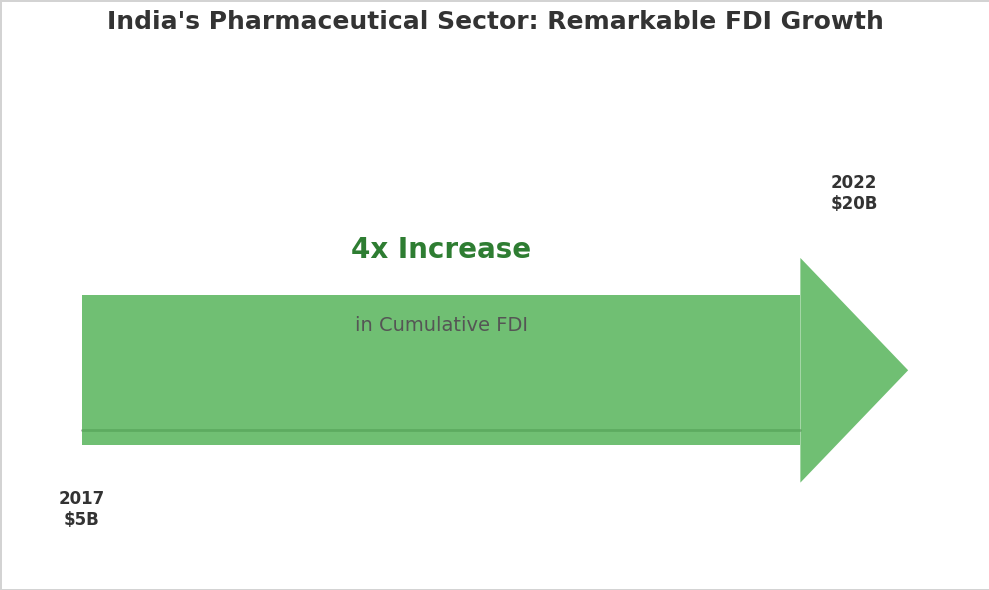

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- Data ---
start_year = 2017
end_year = 2022
start_fdi = 5  # $5 Billion (calculated as $20B / 4)
end_fdi = 20   # $20 Billion

# --- Chart Setup ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#f7f7f7') # Light grey background for the plot area

# --- Visual Elements ---

# 1. Base Line/Bar for the Starting Point
ax.plot([0, 1], [0, 0], color='#a0a0a0', linewidth=2, solid_capstyle='round') # A subtle line

# 2. Large Arrow/Bar Representing Growth
# Define the coordinates for a custom arrow shape or a very thick bar
# We'll use a thick rectangle and then add a triangle for the arrowhead
bar_height = 0.5
y_center = 0.2 # Position the main bar slightly above the base line

# Rectangle for the body of the growth bar
rect = patches.Rectangle((0, y_center - bar_height/2), # (x,y) lower-left
                         (end_fdi / end_fdi), # width normalized to show progress
                         bar_height, # height
                         facecolor='#4CAF50', # Green for growth
                         edgecolor='none',
                         alpha=0.8,
                         zorder=2) # Ensure it's above other elements
ax.add_patch(rect)

# Triangle for the arrowhead
arrowhead_width = 0.15 # relative to total width
arrowhead_height = bar_height * 1.5 # taller than the bar for emphasis

arrowhead = patches.Polygon(np.array([
    [1, y_center - arrowhead_height/2],
    [1 + arrowhead_width, y_center],
    [1, y_center + arrowhead_height/2]
]), facecolor='#4CAF50', edgecolor='none', alpha=0.8, zorder=2)
ax.add_patch(arrowhead)


# --- Annotations and Text ---

# Starting point label
ax.text(0, y_center - bar_height/2 - 0.15, f'{start_year}\n${start_fdi}B',
        ha='center', va='top', fontsize=12, color='#333333', fontweight='bold')

# End point label
ax.text(1 + arrowhead_width/2, y_center + arrowhead_height/2 + 0.15, f'{end_year}\n${end_fdi}B',
        ha='center', va='bottom', fontsize=12, color='#333333', fontweight='bold')

# "Four-fold Rise" text
ax.text(0.5, y_center + 0.4, '4x Increase',
        ha='center', va='center', fontsize=20, color='#2e7d32', fontweight='bold')
ax.text(0.5, y_center + 0.15, 'in Cumulative FDI',
        ha='center', va='center', fontsize=14, color='#555555')


# --- Titles and Labels ---
ax.set_title("India's Pharmaceutical Sector: Remarkable FDI Growth",
             fontsize=18, fontweight='bold', color='#333333', pad=30)
ax.set_xlabel('Over a Five-Year Period', fontsize=12, color='#555555', labelpad=15)


# --- Aesthetics ---
ax.set_xlim(-0.1, 1 + arrowhead_width + 0.1) # Adjust x-limits
ax.set_ylim(-0.5, 1.2) # Adjust y-limits

ax.axis('off') # Hide axes for a clean, infographic-style look

# Add a subtle border to the figure
fig.patch.set_edgecolor('lightgray')
fig.patch.set_linewidth(1)

plt.tight_layout()
plt.savefig('pharma_fdi_growth_chart.png', dpi=300, bbox_inches='tight')
plt.show()

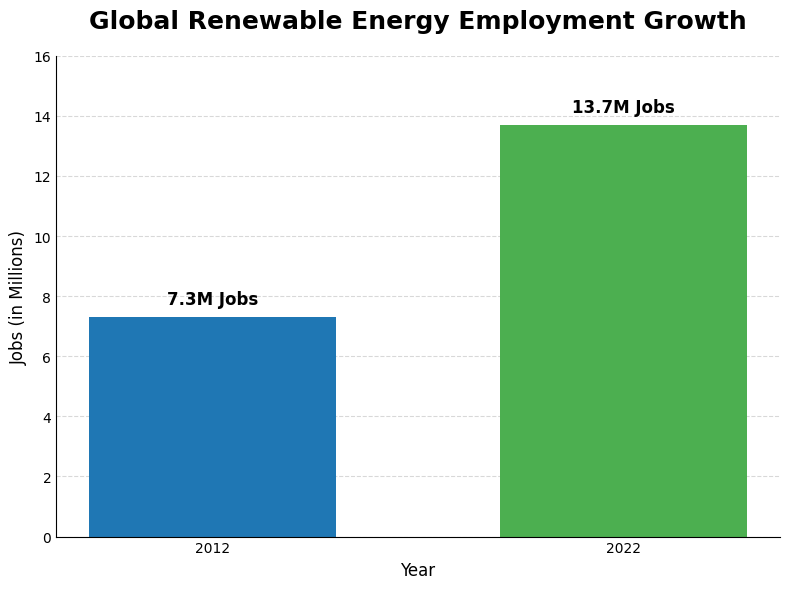

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
years = ['2012', '2022'] # Use strings for categorical labels on x-axis
jobs = [7.3, 13.7]  # In millions

# --- Chart Setup ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1f77b4', '#4CAF50'] # Blue for 2012, Green for 2022

# --- Plotting ---
bars = ax.bar(years, jobs, color=colors, width=0.6)

# --- Annotations and Text ---
# Add text labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3,
            f'{yval}M Jobs', 
            ha='center', va='bottom', 
            fontsize=12, fontweight='bold')

# --- Titles and Labels ---
ax.set_title('Global Renewable Energy Employment Growth', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Jobs (in Millions)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)

# --- Aesthetics ---
# Set Y-axis limits to give space for text
ax.set_ylim(0, 16)

# Add a light horizontal grid for readability
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.3)
ax.set_axisbelow(True) # Put grid behind bars

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Set tick parameters
ax.tick_params(axis='x', which='both', length=0) # Hide x-axis ticks
ax.tick_params(axis='y', which='both', length=0) # Hide y-axis ticks

plt.tight_layout()
plt.savefig('renewable_jobs_bar_chart.png', dpi=300)
plt.show()

In [4]:
import pandas as pd

df = pd.read_csv("train.csv")
df.shape

(3960, 82)

In [5]:
df.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

In [51]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split

# === Load data ===
df = pd.read_csv("train.csv")

# Keep original columns for reference if needed
orig_columns = df.columns.tolist()

season_map = {"spring": "typeA", "summer": "typeB", "fall": "typeC", "autumn": "typeD", "winter": "typeE"}

def map_season_cell(x):
    # Only operate on strings (object dtype)
    if isinstance(x, str):
        s = x.strip().lower()
        if s in season_map:
            return season_map[s]
    return x

# Apply to all object dtype columns (safe and fast)
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].apply(map_season_cell)

# === 2) Rename original 'sii' -> 'target' (preserve it) ===
if "sii" in df.columns:
    df.rename(columns={"sii": "target"}, inplace=True)

# === 3) Clean column names by removing season words (case-insensitive) ===
def remove_season_words_from_col(col):
    # remove whole-word occurrences of season words (case-insensitive)
    new = re.sub(r"(?i)\b(?:spring|summer|fall|autumn|winter)\b", "", col)
    # tidy up leftover separators like double hyphens or underscores and whitespace
    new = re.sub(r"[-_\s]{2,}", "_", new)   # collapse repeated separators
    new = new.strip(" _-")                   # strip separators at ends
    return new if new else col               # fallback to original if empty

cleaned_cols = [remove_season_words_from_col(c) for c in df.columns]
df.columns = cleaned_cols

# === 4) Generate Excel-style column names and assign them, preserving 'target' ===
def excel_labels(n):
    labels = []
    i = 0
    while len(labels) < n:
        j = i
        name = ""
        while True:
            j, remainder = divmod(j, 26)
            name = chr(65 + remainder) + name
            if j == 0:
                break
            j -= 1
        labels.append(name)
        i += 1
    return labels

# Build final mapping: non-target columns -> A,B,C..., target remains 'target'
cols = df.columns.tolist()
num_non_target = sum(1 for c in cols if c != "target")
excel_names = excel_labels(num_non_target)

mapping = {}
excel_idx = 0
for c in cols:
    if c == "target":
        mapping[c] = "target"
    else:
        mapping[c] = excel_names[excel_idx]
        excel_idx += 1

df = df.rename(columns=mapping)

# === 5) Show new columns (optional) ===
print("Column rename mapping (old -> new) sample:")
for old, new in list(mapping.items())[:20]:
    print(f"{old} -> {new}")
print("...")

print("\nFinal columns:")
print(df.columns.tolist())

# === 6) Split into train/val/test (70/15/15) ===
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, shuffle=True)

# === 7) Save splits and mapping ===
train_df.to_csv("train_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

# Save mapping for reference
pd.DataFrame(list(mapping.items()), columns=["old_name", "new_name"]).to_csv("column_mapping.csv", index=False)
print("Saved column_mapping.csv for reference.")


Column rename mapping (old -> new) sample:
id -> A
Basic_Demos-Enroll_Season -> B
Basic_Demos-Age -> C
Basic_Demos-Sex -> D
CGAS-Season -> E
CGAS-CGAS_Score -> F
Physical-Season -> G
Physical-BMI -> H
Physical-Height -> I
Physical-Weight -> J
Physical-Waist_Circumference -> K
Physical-Diastolic_BP -> L
Physical-HeartRate -> M
Physical-Systolic_BP -> N
Fitness_Endurance-Season -> O
Fitness_Endurance-Max_Stage -> P
Fitness_Endurance-Time_Mins -> Q
Fitness_Endurance-Time_Sec -> R
FGC-Season -> S
FGC-FGC_CU -> T
...

Final columns:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AI', 'AJ', 'AK', 'AL', 'AM', 'AN', 'AO', 'AP', 'AQ', 'AR', 'AS', 'AT', 'AU', 'AV', 'AW', 'AX', 'AY', 'AZ', 'BA', 'BB', 'BC', 'BD', 'BE', 'BF', 'BG', 'BH', 'BI', 'BJ', 'BK', 'BL', 'BM', 'BN', 'BO', 'BP', 'BQ', 'BR', 'BS', 'BT', 'BU', 'BV', 'BW', 'BX', 'BY', 'BZ', 'CA', 'CB', 'CC', 'targ

In [52]:
import pandas as pd

df = pd.read_csv("test_split.csv")
df.columns

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N',
       'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB',
       'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AI', 'AJ', 'AK', 'AL', 'AM', 'AN',
       'AO', 'AP', 'AQ', 'AR', 'AS', 'AT', 'AU', 'AV', 'AW', 'AX', 'AY', 'AZ',
       'BA', 'BB', 'BC', 'BD', 'BE', 'BF', 'BG', 'BH', 'BI', 'BJ', 'BK', 'BL',
       'BM', 'BN', 'BO', 'BP', 'BQ', 'BR', 'BS', 'BT', 'BU', 'BV', 'BW', 'BX',
       'BY', 'BZ', 'CA', 'CB', 'CC', 'target'],
      dtype='object')

In [53]:
df = df.iloc[:, :-1]

In [54]:
len(df.columns)

81

In [55]:
df.to_csv("test_split_without_target.csv")

In [56]:
import pandas as pd

# === Step 1: Load the test split ===
df = pd.read_csv("test_split.csv")

# === Step 2: Keep only 'A' and 'target' columns ===
if "A" not in df.columns or "target" not in df.columns:
    raise ValueError("Error: 'A' or 'target' column not found in test_split.csv")

sample_submission = df[["A"]].copy()
sample_submission["target"] = 0  # placeholder prediction (e.g., zeros)

# === Step 3: Save to CSV ===
sample_submission.to_csv("sample_submission.csv", index=False)

print("✅ sample_submission.csv generated with columns: A, target")
print(sample_submission.head())


✅ sample_submission.csv generated with columns: A, target
          A  target
0  0884aca8       0
1  3e3c242c       0
2  75311a3f       0
3  2b3a6805       0
4  1314bc8c       0


In [21]:
import pandas as pd
import numpy as np

# Load the test split
test_df = pd.read_csv("test_split.csv")

# Select top 10 columns + the ID column (assuming 'A' is ID)
id_col = "A"
top_cols = test_df.columns[:10]  # first 10 feature columns

# Prepare sandbox submission
sandbox_df = pd.DataFrame()
sandbox_df[id_col] = test_df[id_col]
sandbox_df["target"] = np.random.rand(len(test_df))  # random float predictions

# Save the sandbox submission
sandbox_df.to_csv("sandbox_submission.csv", index=False)

print(f"✅ sandbox_submission.csv created with shape {sandbox_df.shape}")
print(sandbox_df.head())

✅ sandbox_submission.csv created with shape (594, 2)
          A    target
0  1e08b1dc  0.531288
1  4dc4ed56  0.548062
2  24a3b16d  0.622009
3  2d0bbbd3  0.805289
4  792d2fa5  0.100244


In [ ]:
import pandas as pd
import numpy as np

# Load test split
test_df = pd.read_csv("test_split.csv")

# Keep only ID column
sandbox_df = test_df[['A']].copy()  # Replace 'A' with your ID column

# Generate dummy labels in the valid range for QWK (e.g., 0-4)
sandbox_df['target'] = np.random.randint(0, 5, size=len(sandbox_df))

# Save sandbox submission
sandbox_df.to_csv("sandbox_submission.csv", index=False)

: 

In [57]:
import pandas as pd

# Load test split
test_df = pd.read_csv("test_split.csv")

# Drop rows with missing target values (if any)
test_df = test_df[test_df['target'].notna()]

# Select required columns
sandbox_df = test_df[['A', 'target']].copy()  # Replace 'A' with your ID column name

# Convert target to int32
sandbox_df['target'] = sandbox_df['target'].astype('int32')

# Save final solution file
sandbox_df.to_csv("solution.csv", index=False)

In [58]:
sandbox_df['target'].describe()

count    543.000000
mean       0.596685
std        0.781089
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: target, dtype: float64

In [59]:
len(sandbox_df['target'])

543

In [60]:
import pandas as pd

train = pd.read_csv("train.csv")

In [61]:
train.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

In [13]:
train["sii"].isna()

0       False
1       False
2       False
3       False
4        True
        ...  
3955    False
3956     True
3957    False
3958    False
3959     True
Name: sii, Length: 3960, dtype: bool

In [62]:
import pandas as pd
import numpy as np

# Load your existing solution file
solution_df = pd.read_csv("solution.csv")

# Create a new DataFrame for sample submission
sample_df = solution_df[['A']].copy()  # Keep only the ID column

# Create dummy target values (for example, random integers between 0–4)
sample_df['target'] = np.random.randint(0, 5, size=len(sample_df)).astype('int32')

# Save as sample submission
sample_df.to_csv("sample_submission.csv", index=False)

In [63]:
len(sample_df)

543

In [64]:
import pandas as pd

# Load test split
test_df = pd.read_csv("test_split.csv")

# Keep only rows with valid targets
test_df = test_df[test_df['target'].notna()].reset_index(drop=True)

# Save updated test_split (only valid targets)
test_df.to_csv("test_split.csv", index=False)

# Create a version without target column
test_without_target = test_df.drop(columns=['target'])

# Save it
test_without_target.to_csv("test_without_target.csv", index=False)

In [65]:
len(test_without_target)

543